<a href="https://colab.research.google.com/github/Jul-Summer/1-PJ-03-_SF_-_-/blob/main/%D0%94%D0%B5%D0%BD%D0%BE%D0%B9%D0%B7%D0%B8%D0%BD%D0%B3_%D0%BD%D0%B0_%D0%B0%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8_DN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задача:**
Заполнить слои автоэнкодера, обучить модель и получить PSNR ≥ 23 dB.

Ноутбук использует STL10, добавляет шум, обучает AutoEncoder и считает PSNR на отдельном validation наборе.

In [1]:
!pip install albumentations -U

In [2]:
# IMPORTS
import random
import numpy as np
from math import log10

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as T

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt

In [3]:
# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [4]:
# AUTOENCODER
#Здесь и происходит выполнение условия:
#заполнить слои автоэнкодера

class AutoEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        # ENCODER

        self.encoder = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        # DECODER

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                128,
                128,
                3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 3, 3, padding=1),

            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [5]:
# DATASET (NOISY + CLEAN)
class NoisySTL10(Dataset):

    def __init__(self):

        self.dataset = torchvision.datasets.STL10(
            root="./data",
            split="train",
            download=True
        )

        self.transform = T.Compose([
            T.Resize((96, 96)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        img, _ = self.dataset[idx]

        clean = self.transform(img)

        sigma = random.uniform(0.03, 0.12)

        noise = torch.randn_like(clean) * sigma

        noisy = clean + noise

        noisy = torch.clamp(noisy, 0.0, 1.0)

        return noisy, clean

In [6]:
# TRAIN / VAL SPLIT
full_dataset = NoisySTL10()

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

100%|██████████| 2.64G/2.64G [07:05<00:00, 6.20MB/s]


Train: 4000
Val: 1000


In [7]:
# DATALOADERS
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

In [8]:
# MODEL + OPTIMIZER
model = AutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4
)

print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", total_params)

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)
Parameters: 446723


In [9]:
# PSNR FUNCTION
def calc_psnr(mse):

    if mse == 0:
        return 100

    return 10 * log10(1.0 / mse)

In [10]:
# TRAINING
epochs = 15

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for noisy, clean in train_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        loss = criterion(output, clean)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.6f}"
    )

Epoch [1/15] Loss: 0.006312
Epoch [2/15] Loss: 0.002620
Epoch [3/15] Loss: 0.002450
Epoch [4/15] Loss: 0.002172
Epoch [5/15] Loss: 0.002121
Epoch [6/15] Loss: 0.002030
Epoch [7/15] Loss: 0.002015
Epoch [8/15] Loss: 0.002094
Epoch [9/15] Loss: 0.001980
Epoch [10/15] Loss: 0.001820
Epoch [11/15] Loss: 0.001836
Epoch [12/15] Loss: 0.001785
Epoch [13/15] Loss: 0.001746
Epoch [14/15] Loss: 0.001800
Epoch [15/15] Loss: 0.001723


In [11]:
# VALIDATION PSNR
model.eval()

mse_total = 0

with torch.no_grad():

    for noisy, clean in val_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        mse = criterion(output, clean)

        mse_total += mse.item()

avg_mse = mse_total / len(val_loader)

avg_psnr = calc_psnr(avg_mse)

print()
print("Validation MSE :", avg_mse)
print("Validation PSNR:", avg_psnr, "dB")


Validation MSE : 0.0013701136958843563
Validation PSNR: 28.63243392371774 dB


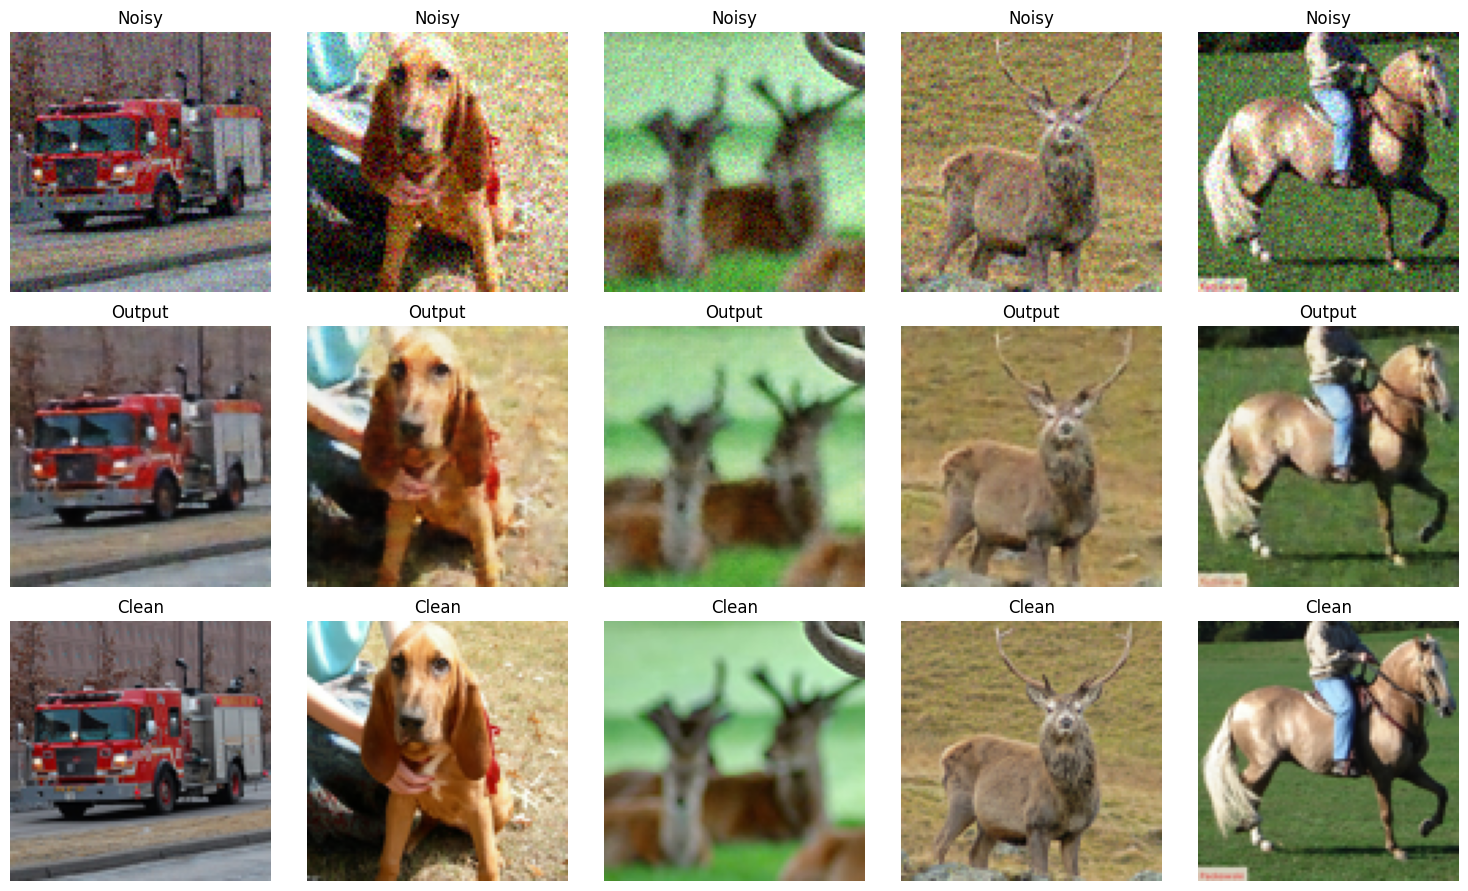

In [12]:
# VISUALIZATION
model.eval()

noisy, clean = next(iter(val_loader))

noisy_gpu = noisy.to(device)

with torch.no_grad():

    output = model(noisy_gpu)

output = output.cpu()

n = 5

plt.figure(figsize=(15, 9))

for i in range(n):

    # NOISY

    plt.subplot(3, n, i + 1)

    plt.imshow(
        noisy[i].permute(1, 2, 0)
    )

    plt.title("Noisy")
    plt.axis("off")

    # OUTPUT

    plt.subplot(3, n, i + 1 + n)

    plt.imshow(
        output[i].permute(1, 2, 0)
    )

    plt.title("Output")
    plt.axis("off")

    # CLEAN

    plt.subplot(3, n, i + 1 + 2*n)

    plt.imshow(
        clean[i].permute(1, 2, 0)
    )

    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Краткий вывод

- Модель демонстрирует хорошее качество восстановления изображений: **низкая ошибка (MSE ≈ 0.00137)** и **высокий PSNR ≈ 28.63 dB** подтверждают, что автоэнкодер эффективно подавляет шум и сохраняет основную структуру изображения, достигая уровня, который считается успешным для задачи денойзинга.